# L4a Advanced: Execution-Aware Probability of Profit

A frictionless terminal rule uses one price for entry and exit. A trade uses different executable prices and may also pay fees and slippage. This notebook adds those cash flows to the L4a probability-of-profit calculation.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
> - **Write the complete cash-flow rule:** Buy at the ask, sell at the bid, and place entry and exit costs at their correct dates.
> - **Translate costs into a lattice threshold:** Derive the minimum terminal mid-price and minimum up-move count needed to clear a strict return target.
> - **Measure the effect of execution costs:** Compare frictionless and execution-aware probabilities and stress-test the assumptions.

Let's get started!
___

## Setup, Data, and Prerequisites

We use a constant-factor binomial lattice under the real-world probability measure. The local `Include.jl` file activates the course project and loads the required packages.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


The `Include.jl` file activates the course project and loads [the `DataFrames.jl` package](https://dataframes.juliadata.org/stable/) for tabular results, [the `Distributions.jl` package](https://juliastats.org/Distributions.jl/stable/) for the binomial distribution, and [the `Plots.jl` package](https://docs.juliaplots.org/stable/) for figures. This notebook defines its own functions, so no local source files are loaded.

In [2]:
default(
    fontfamily = "Helvetica",
    framestyle = :box,
    background_color = :gray97,
    background_color_outside = :white,
    legend_background_color = nothing,
    linewidth = 2,
);

___

## 1. Specify the executable cash flows

Let $S_0^{\mathrm{mid}}$ be the entry-date mid-price. If the quoted full spread is $s$, the entry ask is

$$S_0^{\mathrm{ask}}=S_0^{\mathrm{mid}}(1+s/2).$$

At terminal node $k$, the modeled mid-price is $S_{N,k}^{\mathrm{mid}}=S_0^{\mathrm{mid}}u^kd^{N-k}$. We model the executable bid after an additional adverse slippage fraction $\ell$ as

$$S_{N,k}^{\mathrm{exit}}=S_{N,k}^{\mathrm{mid}}(1-s/2)(1-\ell).$$

For $n_0$ shares, let $F_0$ and $F_T$ denote entry and exit fees. The initial cash outlay and time-0 net present value are

$$C_0=n_0S_0^{\mathrm{ask}}+F_0,$$

$$\Pi_0(k)=e^{-g_bT}\left(n_0S_{N,k}^{\mathrm{exit}}-F_T\right)-C_0,$$

and the execution-aware fractional return is $\rho_N(k)=\Pi_0(k)/C_0$. The frictionless L4a rule scales NPV by the initial share cost. Here, $C_0$ includes the entry fee, so the denominator is the complete initial cash outlay. Either convention is valid if it is stated and used consistently.

In [3]:
S₀_mid = 100.0
u = 1.015
d = 0.990
p = 0.52
N = 20
Δt = 1 / 252
g_b = 0.04
n₀ = 100
ρ_star = 0.04

execution = (
    spread_bps = 50.0,
    slippage_bps = 15.0,
    fixed_fee_per_side = 1.0,
    per_share_fee = 0.005,
)

@assert 0 < d < u
@assert 0 < p < 1
@assert ρ_star > -1
(S₀_mid=S₀_mid, u=u, d=d, p=p, N=N, Δt=Δt, g_b=g_b, shares=n₀, target=ρ_star, execution=execution)

(S₀_mid = 100.0, u = 1.015, d = 0.99, p = 0.52, N = 20, Δt = 0.003968253968253968, g_b = 0.04, shares = 100, target = 0.04, execution = (spread_bps = 50.0, slippage_bps = 15.0, fixed_fee_per_side = 1.0, per_share_fee = 0.005))

___

## 2. Evaluate every terminal node

The function below keeps every quantity in one unit system. Spread and slippage inputs are quoted in basis points, where one basis point is $10^{-4}$. Entry costs are paid now; exit costs are subtracted from the terminal proceeds before discounting.

In [4]:
function terminal_outcomes(;
    S₀_mid::Real, u::Real, d::Real, p::Real, N::Int, Δt::Real, g_b::Real,
    n₀::Int, ρ_star::Real, spread_bps::Real=0.0, slippage_bps::Real=0.0,
    fixed_fee_per_side::Real=0.0, per_share_fee::Real=0.0,
)
    @assert S₀_mid > 0 && 0 < d < u && 0 <= p <= 1 && N >= 1 && Δt > 0 && n₀ > 0
    @assert spread_bps >= 0 && slippage_bps >= 0
    @assert fixed_fee_per_side >= 0 && per_share_fee >= 0

    half_spread = spread_bps / 20_000
    slippage = slippage_bps / 10_000
    @assert half_spread < 1 && slippage < 1

    entry_ask = S₀_mid * (1 + half_spread)
    entry_fee = fixed_fee_per_side + n₀ * per_share_fee
    exit_fee = fixed_fee_per_side + n₀ * per_share_fee
    initial_outlay = n₀ * entry_ask + entry_fee
    discount_factor = exp(-g_b * N * Δt)
    distribution = Binomial(N, p)

    rows = NamedTuple[]
    for k in 0:N
        terminal_mid = S₀_mid * u^k * d^(N-k)
        exit_price = terminal_mid * (1 - half_spread) * (1 - slippage)
        discounted_exit = discount_factor * (n₀ * exit_price - exit_fee)
        npv = discounted_exit - initial_outlay
        ρ = npv / initial_outlay
        push!(rows, (
            up_moves=k, probability=pdf(distribution, k), terminal_mid=terminal_mid,
            executable_exit=exit_price, npv=npv, ρ=ρ, success=ρ > ρ_star,
        ))
    end

    outcomes = DataFrame(rows)
    @assert isapprox(sum(outcomes.probability), 1.0; atol=1e-12)
    @assert issorted(outcomes.ρ)
    successful_counts = outcomes.up_moves[outcomes.success]
    k_min = isempty(successful_counts) ? N + 1 : minimum(successful_counts)
    probability_of_profit = sum(outcomes.probability[outcomes.success])

    return (
        outcomes=outcomes, entry_ask=entry_ask, initial_outlay=initial_outlay,
        entry_fee=entry_fee, exit_fee=exit_fee, k_min=k_min,
        probability_of_profit=probability_of_profit,
    )
end

terminal_outcomes (generic function with 1 method)

In [5]:
common = (S₀_mid=S₀_mid, u=u, d=d, p=p, N=N, Δt=Δt, g_b=g_b, n₀=n₀, ρ_star=ρ_star)
frictionless = terminal_outcomes(; common...)
execution_aware = terminal_outcomes(; common..., execution...)

comparison = DataFrame(
    model = ["Frictionless", "Execution aware"],
    entry_price = [frictionless.entry_ask, execution_aware.entry_ask],
    initial_outlay = [frictionless.initial_outlay, execution_aware.initial_outlay],
    minimum_up_moves = [frictionless.k_min, execution_aware.k_min],
    probability_of_profit = [frictionless.probability_of_profit, execution_aware.probability_of_profit],
)
@assert execution_aware.probability_of_profit <= frictionless.probability_of_profit + 1e-12
comparison

Row,model,entry_price,initial_outlay,minimum_up_moves,probability_of_profit
,String,Float64,Float64,Int64,Float64
1,Frictionless,100.0,10000.0,10,0.656841
2,Execution aware,100.25,10026.5,11,0.483443


In [6]:
boundary_counts = sort(unique(clamp.([
    frictionless.k_min - 1, frictionless.k_min,
    execution_aware.k_min - 1, execution_aware.k_min,
], 0, N)))
select(
    execution_aware.outcomes[in.(execution_aware.outcomes.up_moves, Ref(boundary_counts)), :],
    :up_moves, :probability, :terminal_mid, :executable_exit, :npv, :ρ, :success,
)

Row,up_moves,probability,terminal_mid,executable_exit,npv,ρ,success
,Int64,Float64,Float64,Float64,Float64,Float64,Bool
1,9,0.145509,102.372,101.963,135.984,0.0135625,false
2,10,0.173398,104.957,104.538,392.65,0.0391613,false
3,11,0.170771,107.608,107.178,655.798,0.0654065,true


___

## 3. Convert the cash-flow rule into an up-count threshold

Let $C_0$ be the initial outlay and write $s/2$ for the half-spread. The strict target $\rho_N(k)>\rho_\star$ is equivalent to

$$S_{N,k}^{\mathrm{mid}}>S_{\min}^{\mathrm{mid}}:=\frac{e^{g_bT}(1+\rho_\star)C_0+F_T}{n_0(1-s/2)(1-\ell)}.$$

Using $S_{N,k}^{\mathrm{mid}}=S_0^{\mathrm{mid}}u^kd^{N-k}$ gives the real-valued count threshold

$$\tau=\frac{\log(S_{\min}^{\mathrm{mid}}/S_0^{\mathrm{mid}})-N\log d}{\log(u/d)},$$

so the smallest successful integer is $k_{\min}=\lfloor\tau\rfloor+1$. The floor-plus-one rule is required because the target is strict.

In [7]:
function analytic_execution_threshold(;
    S₀_mid::Real, u::Real, d::Real, N::Int, Δt::Real, g_b::Real, n₀::Int,
    ρ_star::Real, spread_bps::Real=0.0, slippage_bps::Real=0.0,
    fixed_fee_per_side::Real=0.0, per_share_fee::Real=0.0,
)
    half_spread = spread_bps / 20_000
    slippage = slippage_bps / 10_000
    entry_fee = fixed_fee_per_side + n₀ * per_share_fee
    exit_fee = fixed_fee_per_side + n₀ * per_share_fee
    initial_outlay = n₀ * S₀_mid * (1 + half_spread) + entry_fee
    minimum_terminal_mid = (
        exp(g_b * N * Δt) * (1 + ρ_star) * initial_outlay + exit_fee
    ) / (n₀ * (1 - half_spread) * (1 - slippage))
    τ = (log(minimum_terminal_mid / S₀_mid) - N * log(d)) / log(u / d)
    return (minimum_terminal_mid=minimum_terminal_mid, τ=τ, k_min=floor(Int, τ) + 1)
end

threshold_inputs = (S₀_mid=S₀_mid, u=u, d=d, N=N, Δt=Δt, g_b=g_b, n₀=n₀, ρ_star=ρ_star)
threshold = analytic_execution_threshold(; threshold_inputs..., execution...)
@assert threshold.k_min == execution_aware.k_min
threshold

(minimum_terminal_mid = 105.04193348419278, τ = 10.032346374283698, k_min = 11)

___

## 4. Separate the effects of spread, fees, and slippage

We add the execution assumptions one group at a time. A change in probability occurs only when the added cost moves the minimum successful integer count. The underlying return changes continuously, but the finite lattice probability changes in steps.

In [8]:
execution_scenarios = [
    (name="Frictionless", spread_bps=0.0, slippage_bps=0.0, fixed_fee_per_side=0.0, per_share_fee=0.0),
    (name="Quoted spread", spread_bps=execution.spread_bps, slippage_bps=0.0, fixed_fee_per_side=0.0, per_share_fee=0.0),
    (name="Spread and fees", spread_bps=execution.spread_bps, slippage_bps=0.0, fixed_fee_per_side=execution.fixed_fee_per_side, per_share_fee=execution.per_share_fee),
    (name="Spread, fees, and slippage", spread_bps=execution.spread_bps, slippage_bps=execution.slippage_bps, fixed_fee_per_side=execution.fixed_fee_per_side, per_share_fee=execution.per_share_fee),
]

component_rows = NamedTuple[]
for scenario in execution_scenarios
    result = terminal_outcomes(;
        common...,
        spread_bps=scenario.spread_bps,
        slippage_bps=scenario.slippage_bps,
        fixed_fee_per_side=scenario.fixed_fee_per_side,
        per_share_fee=scenario.per_share_fee,
    )
    push!(component_rows, (
        scenario=scenario.name, k_min=result.k_min,
        probability_of_profit=result.probability_of_profit,
    ))
end
component_table = DataFrame(component_rows)

Row,scenario,k_min,probability_of_profit
,String,Int64,Float64
1,Frictionless,10,0.656841
2,Quoted spread,10,0.656841
3,Spread and fees,10,0.656841
4,"Spread, fees, and slippage",11,0.483443


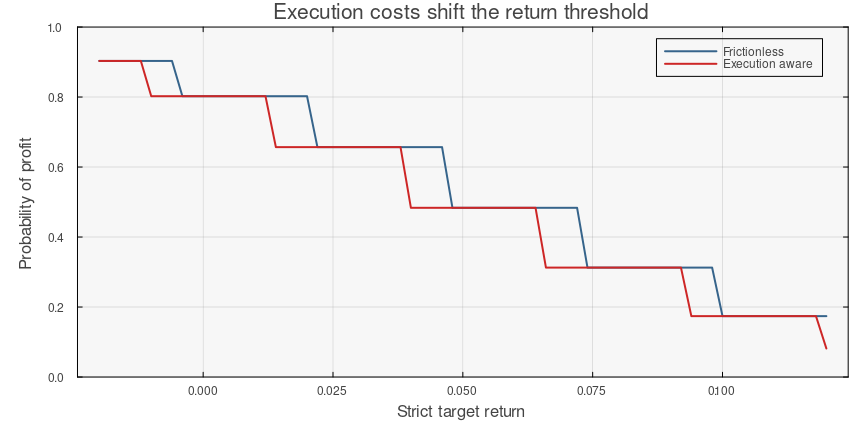

In [9]:
target_grid = collect(range(-0.02, 0.12; length=71))
frictionless_curve = [terminal_outcomes(; merge(common, (ρ_star=target,))...).probability_of_profit for target in target_grid]
execution_curve = [terminal_outcomes(; merge(common, (ρ_star=target,))..., execution...).probability_of_profit for target in target_grid]

plot(
    target_grid, frictionless_curve;
    color=:steelblue4, label="Frictionless",
    xlabel="Strict target return", ylabel="Probability of profit",
    title="Execution costs shift the return threshold",
    ylim=(0, 1), yticks=0:0.2:1.0, size=(860, 440),
    left_margin=7mm, bottom_margin=7mm,
)
plot!(target_grid, execution_curve; color=:firebrick3, label="Execution aware")

___

## 5. Stress-test the benchmark and holding period

The benchmark growth rate changes the return hurdle. The holding period changes both the hurdle and the distribution of the up-move count. We therefore recompute the complete probability for every pair rather than infer a direction from the discount factor alone.

In [10]:
horizons = [5, 10, 20, 40]
benchmark_rates = [0.00, 0.04, 0.08]
stress_rows = NamedTuple[]
for horizon in horizons, benchmark_rate in benchmark_rates
    assumptions = merge(common, (N=horizon, g_b=benchmark_rate))
    result = terminal_outcomes(; assumptions..., execution...)
    push!(stress_rows, (
        steps=horizon, years=horizon*Δt, benchmark_growth_rate=benchmark_rate,
        k_min=result.k_min, probability_of_profit=result.probability_of_profit,
    ))
end
stress_table = DataFrame(stress_rows)

Row,steps,years,benchmark_growth_rate,k_min,probability_of_profit
,Int64,Float64,Float64,Int64,Float64
1,5,0.0198413,0.0,4,0.213499
2,5,0.0198413,0.04,4,0.213499
3,5,0.0198413,0.08,4,0.213499
4,10,0.0396825,0.0,6,0.427048
5,10,0.0396825,0.04,6,0.427048
6,10,0.0396825,0.08,7,0.206652
7,20,0.0793651,0.0,10,0.656841
8,20,0.0793651,0.04,11,0.483443
9,20,0.0793651,0.08,11,0.483443


___

## 6. Know what remains simplified

This model treats the spread, fees, and slippage as known constants. Under those assumptions, terminal return remains increasing in the up-move count, so the successful states still form a binomial tail.

Real execution can depend on time, trade size, volatility, order type, and available liquidity. If costs depend on the state or path, a single count threshold may no longer describe the successful event. That requires a richer execution model, not merely a larger fee estimate.

___

## Summary

This notebook replaced the frictionless price comparison with dated executable cash flows.

> __Key Takeaways:__
>
> - **Probability of profit begins with cash flows:** Entry and exit prices, fees, horizon, benchmark growth rate, and target must all be specified.
> - **Deterministic execution costs preserve the binomial tail:** They raise the return hurdle, which may move the strict count threshold, but they do not change the real-world node probabilities.
> - **Finite lattices produce step changes:** A small extra cost changes the probability only when it moves the minimum successful up-move count to the next integer, and then the change is discrete.

Because spread, fees, and slippage raise the price and up-count thresholds required to clear a return target, a quoted probability of profit is meaningful only alongside its execution assumptions.

___

## Disclaimer and Risks

This notebook is for instruction only. Its execution assumptions are simplified and are not estimates of the cost of any specific trade. Actual fills can differ from quoted prices and may be partial or delayed. This material is not investment or trading advice.

___